# Spatial Lapse Rate from Juneau Icefield Temperature Data

### Prep to import Juneau Icefield temperature data at daily resolution

In [10]:
import glob

root_folder = '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/'

# Get only daily files (i.e. no hourly files)
file_list = glob.glob(root_folder+'*_daily*.csv')

print(file_list)
print(len(file_list))

['/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefieldCamp18AWS_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1196_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1293_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield2050_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1705_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefieldCamp17AWS_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield2121_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1285_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1618_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1445_daily_LVL2.csv', '/Users/j

In [2]:
import pandas as pd
pd.get_option("display.max_columns")

def load_dataframe(file_path, index_col):
    
    df = pd.read_csv(file_path, header=0, index_col=index_col)
    
    df.index = pd.DatetimeIndex(df.index)
    
    return df

### Check out one of the files using a pandas dataframe

In [8]:
file_path = file_list[0]

df = load_dataframe(file_path, 'Date')

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir
Date,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN


In [9]:
# Prep the data to average to annual resolution

df['year'] = df.index.year
df['month'] = df.index.month

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir,year,month
Date,,,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN,2012,7
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN,2012,7
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0,2012,7
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0,2012,7
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0,2012,7
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0,2012,7
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN,2012,7
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0,2012,7
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN,2012,7


In [11]:
# Average the dataframe to annual resolution

df.groupby('year').mean().head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir,month
year,,,,,,,,,,
2012,-4.700000,-1.233143,-2.964571,-3.001714,6.022286,84.342286,NaN,5.518935,167.206349,9.622857
2013,-7.824706,-3.208235,-5.518824,-5.618235,6.008235,82.782645,NaN,4.452050,154.094340,6.526027
2014,NaN,NaN,NaN,NaN,NaN,80.314972,NaN,5.158559,154.822034,6.526027
2015,NaN,NaN,NaN,NaN,NaN,84.304457,NaN,4.908735,157.256198,6.526027
2016,-4.911475,-1.485246,-3.201639,-3.400000,NaN,82.889426,NaN,5.189241,154.156863,6.513661
2017,-5.302740,-1.225205,-3.267123,-3.604658,NaN,80.522072,NaN,9.071429,104.222222,6.526027
2018,-7.439080,-2.932759,-5.181034,-5.620115,NaN,51.900000,NaN,NaN,NaN,3.408046


### Plot the annually-averaged maximum temperature data for each station on the icefield

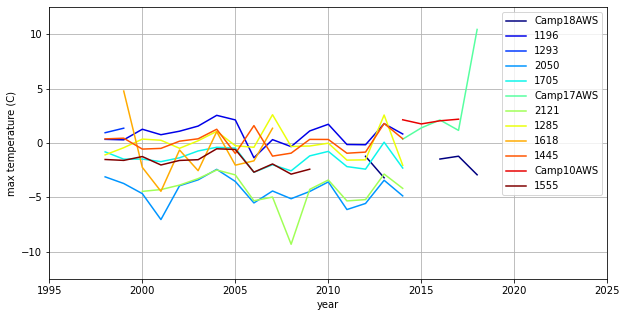

In [12]:
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.jet(np.linspace(0,1,len(file_list)))

plt.figure(figsize=(10,5))

# load each station file, average to annual resolution, grab the elevation, and plot
for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df_yr = df.groupby('year').mean()
    
    label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
    plt.plot(df_yr.index.values, df_yr['site_temp_max'],
             '-', color=colors[ii], label=label)

plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
plt.ylim([-12.5,12.5])
plt.xlim([1995,2025])
plt.show()

Is there a relationship between elevation and temperature? (The elevation is the label with units of meters.)

### Plot daily maximum temperatures for each station for the year 2002

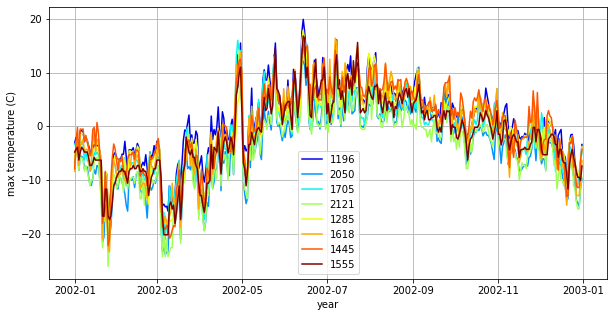

In [13]:
plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[df['year']==2002]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.index.values, df_2002_nona.values,
                 '-', color=colors[ii], label=label)

plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show()  

### Plot elevation vs. annually-averaged USGS site temperature for the year 2002 and calculate the spatial lapse rate

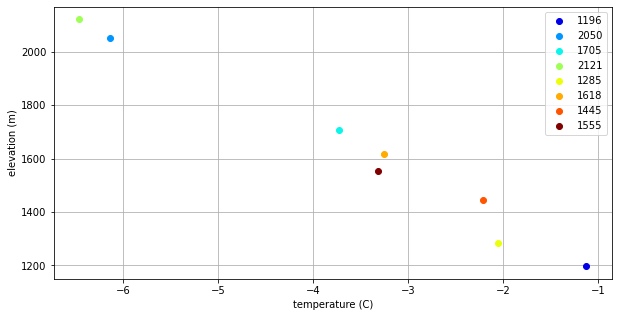

In [19]:
elvs = []
Ts = []

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_USGS'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show() 

In [20]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9901290269158615
P-value = 2.386707314786073e-06
Slope =  -0.005675132817404084
Intercept =  5.668294394391631


### Plot elevation vs. January USGS site temperature and calculate the spatial lapse rate

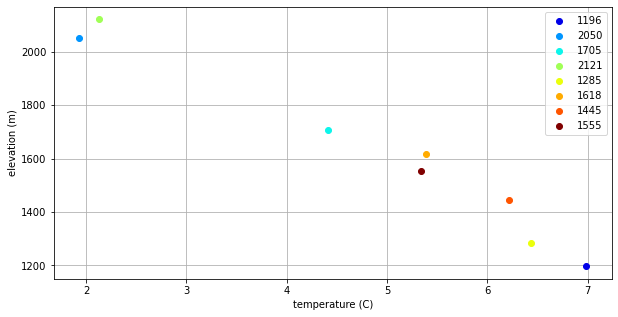

In [26]:
elvs = []
Ts = []

month = 8
#year = 2002

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    # Choose this line of code to average over one year
    #df_2002 = df[(df['year']==year) & (df['month']==month)]
    
    # Choose the next two lines of code to average over all years
    foo = df[df['month']==month]
    df_2002 = foo.groupby('year').mean()
    
    df_2002_nona = df_2002['site_temp_USGS'].dropna()
    
    if len(df_2002_nona) > 5:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
    
        #plt.plot(df_2002_nona.values, np.tile(int(label),df_2002_nona.shape),
        #         'o', color=colors[ii], label=label)
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show() 

In [27]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9832907318496411
P-value = 1.151738184197737e-05
Slope =  -0.005670632563874948
Intercept =  14.052389560397284


In [28]:
for month in range(1, 13):
    elvs = []
    Ts = []
    
    for ii, file_path in enumerate(file_list):  
        df = load_dataframe(file_path, 'Date')
        df['year'] = df.index.year
        df['month'] = df.index.month

        # Choose this line of code to average over one year
        #df_2002 = df[(df['year']==year) & (df['month']==month)]

        # Choose the next two lines of code to average over all years
        foo = df[df['month']==month]
        df_2002 = foo.groupby('year').mean()

        df_2002_nona = df_2002['site_temp_USGS'].dropna()

        if len(df_2002_nona) > 5:

            label = file_path.split('/')[-1].split('_')[0].split('field')[-1]

            plt.plot(df_2002_nona.values.mean(), int(label),
                     'o', color=colors[ii], label=label)

            #plt.plot(df_2002_nona.values, np.tile(int(label),df_2002_nona.shape),
            #         'o', color=colors[ii], label=label)

            elvs = elvs + [int(label)]
            Ts = Ts + [df_2002_nona.values.mean()]
    
    r, p_value = stats.pearsonr(elvs,Ts)
    slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

    print('Month = ' + str(month) + 'Slope = ' + str(slope))

IndentationError: expected an indented block (2739457801.py, line 1)

How do the lapse rates of the min and max temperatures differ?

How do the lapse rates differ by month?

How do the lapse rates differ by year?

Can you plot the best-fit line on the graph?

Why are the lapse rates noticeably lower in the winter months?

### Where are these stations?

In [17]:
loc_file_path = '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/WeatherStationLocations.csv'
df_locs = pd.read_csv(loc_file_path, header=0, index_col='Elevation')

df_locs.head(10)

,Location,Latitude,Longitude,NWIS ID
Elevation,,,,
1196,C-10,59.575640,-133.709820,NaN
1285,C-17,58.647210,-134.206350,NaN
1445,C-26,58.367370,-134.366380,NaN
1555,C-9,59.016640,-134.121040,NaN
1618,C-29,58.712433,-134.182217,NaN
1705,C-18,59.342110,-134.102210,NaN
2050,C-8,58.834970,-134.276430,NaN
2121,C-25,58.806700,-134.136130,NaN


Text(-133, 58.3019, 'Juneau')

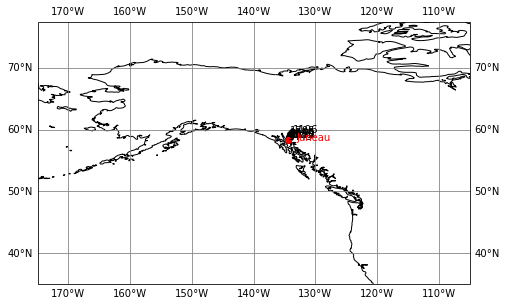

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cf 
from matplotlib.offsetbox import AnchoredText

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-175, -105, 35, 75], ccrs.Geodetic())

ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)
ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1) 

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)

ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-133, 58.3019, 'Juneau', color='r', transform=proj)

Text(-134.4197, 58.3019, '17')

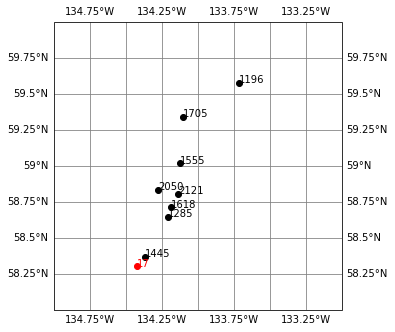

In [30]:
proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

#ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

### The following compares the lapse rates to ERA5 data, which we can do if we have time. For now, let's skip this.

In [ ]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 'z_Amon_ERA5_2002.nc'

import xarray as xr
ds_z_full = xr.open_dataset(file_path+file_name)
ds_z = ds_z_full.sel(longitude=slice(-175 % 360, -105 % 360), latitude=slice(75, 35), time='2002-01-01')

z_plot = np.squeeze(ds_z.z.values)

longitudes = ((ds_z['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_z.latitude.values)

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, z_plot/9.81, cmap='viridis', 
                   vmin=0, vmax=2000, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('meters', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

In [150]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 't2m_Amon_ERA5_1979-2020.nc'

import xarray as xr
ds_t_full = xr.open_dataset(file_path+file_name)
ds_t = ds_t_full.sel(longitude=slice(-175 % 360, -105 % 360), 
                     latitude=slice(75, 35))#, 
                     #time=slice('2002-01-01','2002-12-01')).mean('time')
                     #time = '2002-01-01')

Text(-134.4197, 58.3019, '17')

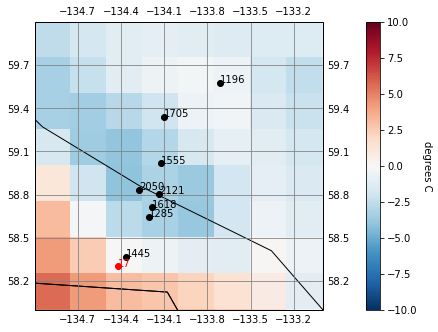

In [152]:
longitudes = ((ds_t['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_t.latitude.values)

t_plot = ds_t.t2m.mean('time').values

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, t_plot-273.15, cmap='RdBu_r', 
                   vmin=-10, vmax=10, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('degrees C', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

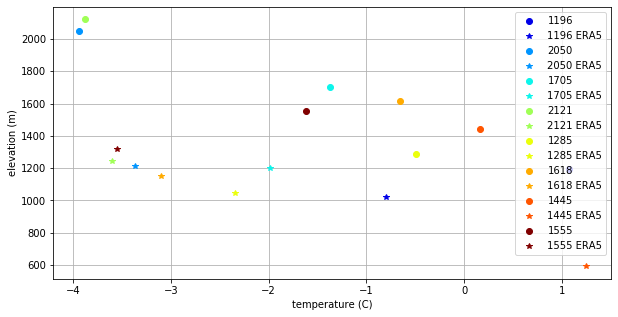

In [153]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time=slice('2002-01-01','2002-12-01')).mean('time')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [154]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9468971919225281
P-value = 0.00035961118399445685
Slope =  -0.005127540373240108
Intercept =  6.975613104492636 

ERA5 Correlation Coefficient = -0.934129966411392
ERA5 P-value = 0.0006796691515283236
ERA5 Slope =  -0.0069227439614270815
ERA5 Intercept =  5.4136943620663995


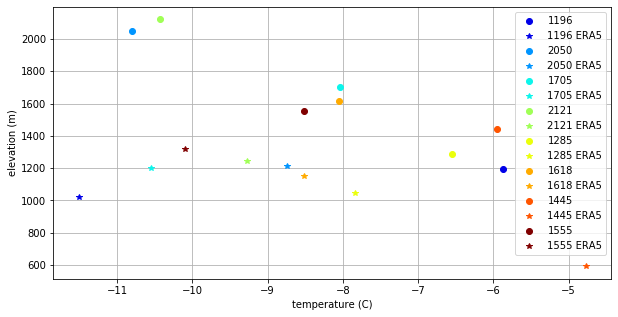

In [157]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002) & (df['month']==1)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) > 0:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time='2002-01-01')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [158]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9459185485572129
P-value = 0.0003795778803346242
Slope =  -0.005375467234423798
Intercept =  0.6876907595407751 

ERA5 Correlation Coefficient = -0.7372418064206353
ERA5 P-value = 0.03688527117407227
ERA5 Slope =  -0.00665477059672018
ERA5 Intercept =  -1.603720856223105


### Now look at our own data!